# Lab: Hough Transform and Image Rectification

**Goal.** In this lab, you will:
- Detect straight lines using the Hough Line Transform and Probabilistic Hough Line Transform.
- Detect circular objects using the Hough Circle Transform.
- Study the effect of Canny edge detection parameters on feature detection.
- Apply planar rectification using perspective transformation.
- Evaluate how rectification affects line detection accuracy.

**Three Topics**
1. Hough line transform and probabilistic Hough line transform.
2. Hough circle transform.
3. Mini-project: rectify a plane and detect lines



## 0. Setup

Run the cells below in Google Colab. The notebook uses only standard scientific Python packages plus OpenCV.

In [ ]:
!pip -q install opencv-python-headless scikit-image

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

np.set_printoptions(precision=3, suppress=True)
%matplotlib inline

def show_image(img, title='', cmap=None, figsize=(6, 6)):
    plt.figure(figsize=figsize)
    if img.ndim == 2:
        plt.imshow(img, cmap=cmap or 'gray')
    else:
        plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.show()



[notice] A new release of pip is available: 24.1.2 -> 26.1
[notice] To update, run: pip install --upgrade pip


## Topic 1. Hough transform for line detection



The Hough transform detects lines by voting in a parameter space. A 2D line can be written as:

$$
\rho = x\cos\theta + y\sin\theta,
$$

where $\rho$ is the perpendicular distance from the origin to the line and $\theta$ is the angle of the line normal.

OpenCV provides:

- `cv2.HoughLines`: standard Hough transform.
- `cv2.HoughLinesP`: probabilistic Hough transform, returning finite line segments.

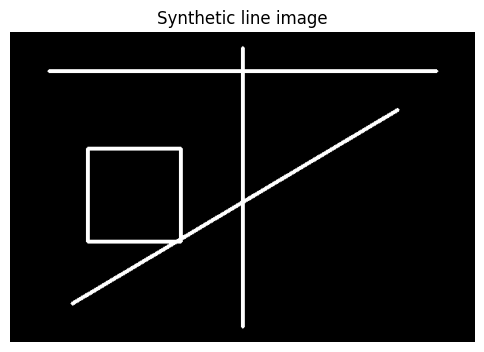

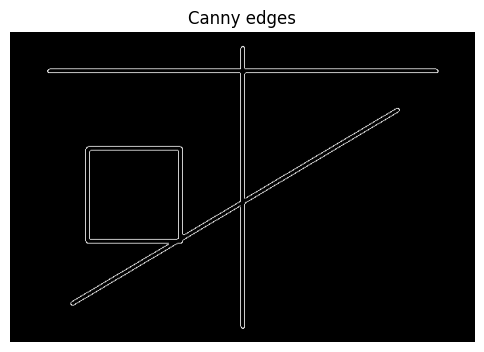

In [ ]:
line_img = np.zeros((400, 600), dtype=np.uint8)
cv2.line(line_img, (50, 50), (550, 50), 255, 3)
cv2.line(line_img, (80, 350), (500, 100), 255, 3)
cv2.line(line_img, (300, 20), (300, 380), 255, 3)
cv2.rectangle(line_img, (100, 150), (220, 270), 255, 3)

show_image(line_img, 'Synthetic line image')


In [ ]:
# 1. implement canny edge detection to extract edges from the line image
edges = ## write your code here


In [ ]:
show_image(edges, 'Canny edges')

In [ ]:
# 2. implement hough transformation for line detection
lines = ## write your code here


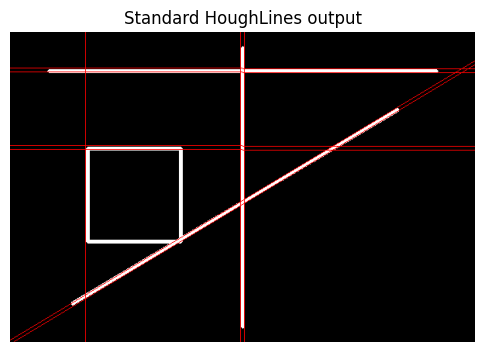

Number of detected standard lines: 9


In [ ]:
output_standard = cv2.cvtColor(line_img, cv2.COLOR_GRAY2RGB)

if lines is not None:
    for line in lines[:20]:
        rho, theta = line[0]
        a, b = np.cos(theta), np.sin(theta)
        x0, y0 = a*rho, b*rho
        x1 = int(x0 + 1000*(-b)); y1 = int(y0 + 1000*(a))
        x2 = int(x0 - 1000*(-b)); y2 = int(y0 - 1000*(a))
        cv2.line(output_standard, (x1, y1), (x2, y2), (255, 0, 0), 1)
show_image(output_standard, 'Standard HoughLines output')
print('Number of detected standard lines:', 0 if lines is None else len(lines))


In [ ]:
# 3. implement the probabilistic hough transformation for line detection
lines_p = 

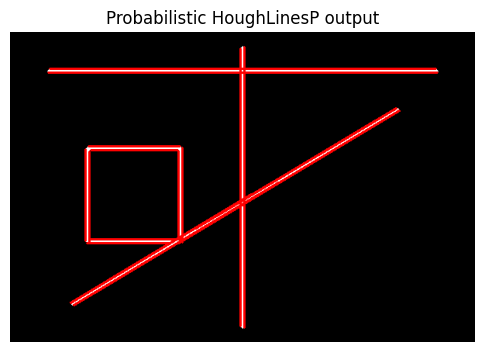

Number of detected line segments: 16


In [ ]:

output_prob = cv2.cvtColor(line_img, cv2.COLOR_GRAY2RGB)

if lines_p is not None:
    for x1, y1, x2, y2 in lines_p[:, 0, :]:
        cv2.line(output_prob, (x1, y1), (x2, y2), (255, 0, 0), 2)
show_image(output_prob, 'Probabilistic HoughLinesP output')
print('Number of detected line segments:', 0 if lines_p is None else len(lines_p))


We now run line detection on a natural image. Hough methods usually work better after edge detection, thresholding, or region masking.

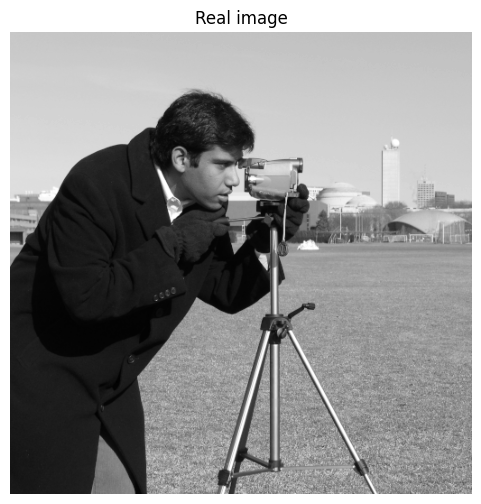

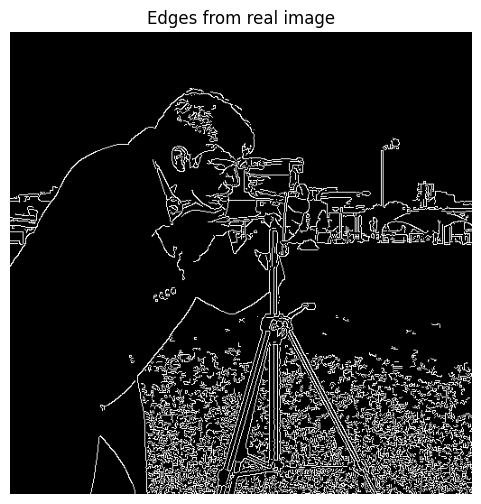

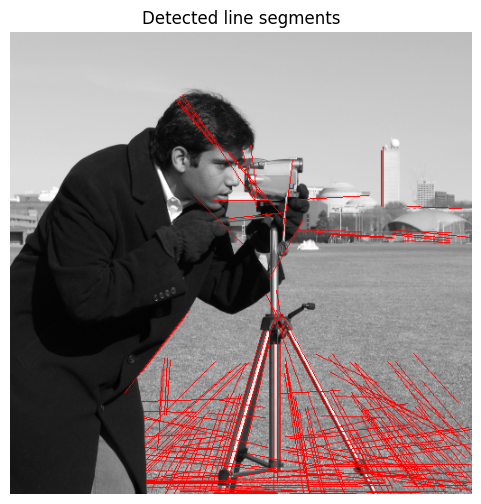

Number of detected line segments: 188


In [ ]:
camera_img = data.camera()
small = cv2.resize(camera_img, (512, 512))
edges_real = ## write edge detection code here, you can reuse the parameters from the previous edge detection step
real_out = cv2.cvtColor(small, cv2.COLOR_GRAY2RGB)


lines_real = ## write your code here ,select a hough transformation method and set appropriate parameters for line detection

if lines_real is not None:
    for x1, y1, x2, y2 in lines_real[:, 0, :]:
        cv2.line(real_out, (x1, y1), (x2, y2), (255, 0, 0), 1)
show_image(small, 'Real image')
show_image(edges_real, 'Edges from real image')
show_image(real_out, 'Detected line segments')
print('Number of detected line segments:', 0 if lines_real is None else len(lines_real))


Question: 
- Adjust the parameters in `cv2.Canny`, `cv2.HoughLines`, `cv2.HoughLinesP` to see the difference of line detection

## Topic 2. Hough circle transform

For circles, the parameter space is usually $(a,b,r)$, where $(a,b)$ is the circle center and $r$ is the radius. OpenCV provides `cv2.HoughCircles`.
- Change the parameters in `cv2.HoughCircles` to see the difference of circle detection

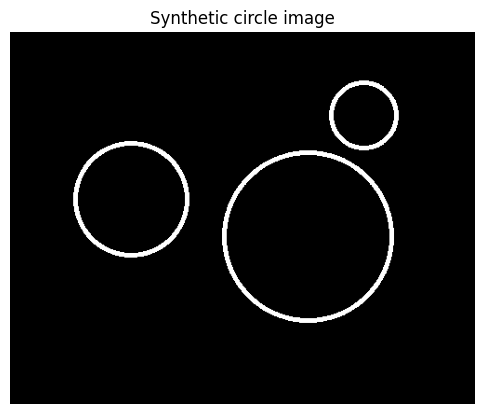

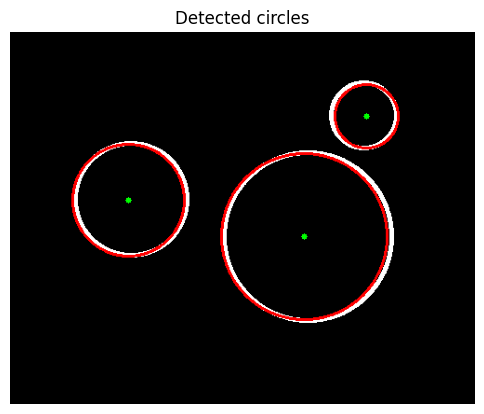

Detected circles [x, y, r]:
[[316 220  89]
 [127 181  60]
 [383  91  34]]


In [ ]:
circle_img = np.zeros((400, 500), dtype=np.uint8)
cv2.circle(circle_img, (130, 180), 60, 255, 3)
cv2.circle(circle_img, (320, 220), 90, 255, 3)
cv2.circle(circle_img, (380, 90), 35, 255, 3)
blurred = cv2.medianBlur(circle_img, 5)

circles = ## write your code here, set appropriate parameters for circle detection
circle_out = cv2.cvtColor(circle_img, cv2.COLOR_GRAY2RGB)
if circles is not None:
    circles = np.round(circles[0]).astype(int)
    for x, y, r in circles:
        cv2.circle(circle_out, (x, y), r, (255, 0, 0), 2)
        cv2.circle(circle_out, (x, y), 3, (0, 255, 0), -1)
show_image(circle_img, 'Synthetic circle image')
show_image(circle_out, 'Detected circles')
print('Detected circles [x, y, r]:')
print(circles if circles is not None else 'None')


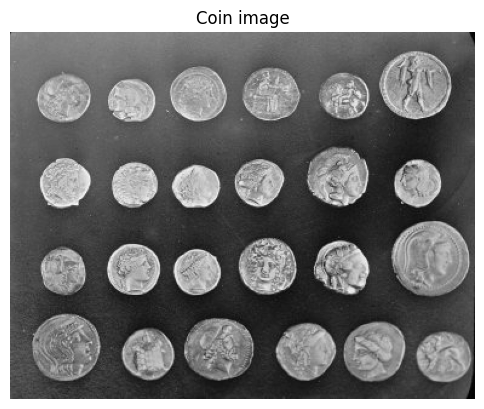

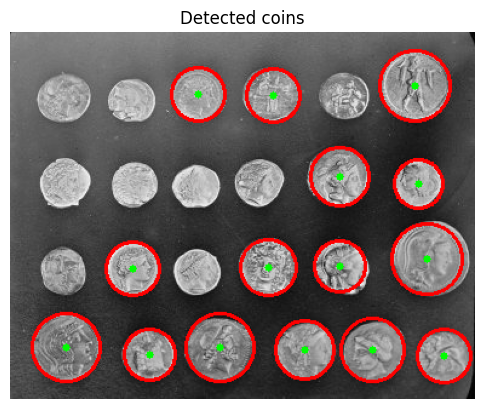

Detected coins [x, y, r]:
[[ 46 260  28]
 [334  44  29]
 [213 194  23]
 [115 266  21]
 [155  51  22]
 [299 262  26]
 [272 119  24]
 [101 195  22]
 [344 187  29]
 [272 193  21]
 [358 267  22]
 [243 262  24]
 [173 260  28]
 [217  52  22]
 [337 125  20]]


In [ ]:
# apply this to coin images
coin_img = data.coins()
coin_blur = cv2.medianBlur(coin_img, 5)
coin_circles = ## write your code here, set appropriate parameters for circle detection
coin_out = cv2.cvtColor(coin_img, cv2.COLOR_GRAY2RGB)
if coin_circles is not None:
    coin_circles = np.round(coin_circles[0]).astype(int)
    for x, y, r in coin_circles:
        cv2.circle(coin_out, (x, y), r, (255, 0, 0), 2)
        cv2.circle(coin_out, (x, y), 3, (0, 255, 0), -1)
show_image(coin_img, 'Coin image')
show_image(coin_out, 'Detected coins')
print('Detected coins [x, y, r]:')
print(coin_circles if coin_circles is not None else 'None')

Question:
1. Which parameter controls how strict the circle detection is?
2. What happens if the radius range is too wide?
3. What happens if `minDist` is too small?

## Task 3: Mini-project: rectify a plane and detect lines

Complete the following mini-project:

1. Use the perspective-view document image as template
2. Identity four corner points.
3. Estimate a homography and rectify the object.
4. Run Canny edge detection on the rectified image and then run Hough line detection.
You may use the starter code below.

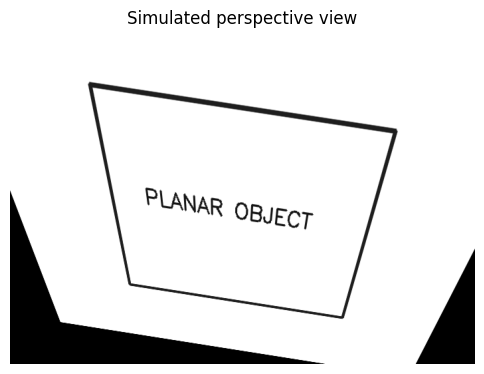

In [ ]:
img_doc = np.ones((500, 700, 3), dtype=np.uint8) * 255
cv2.rectangle(img_doc, (160, 120), (540, 390), (30, 30, 30), 3)
cv2.putText(img_doc, 'PLANAR OBJECT', (210, 250), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (20, 20, 20), 2)

src_rect = np.float32([[160, 120], [540, 120], [540, 390], [160, 390]])
dst_quad = np.float32([[120, 80], [580, 150], [500, 430], [180, 380]])
H_sim = cv2.getPerspectiveTransform(src_rect, dst_quad)
perspective_view = cv2.warpPerspective(img_doc, H_sim, (700, 500))
show_image(perspective_view, 'Simulated perspective view')

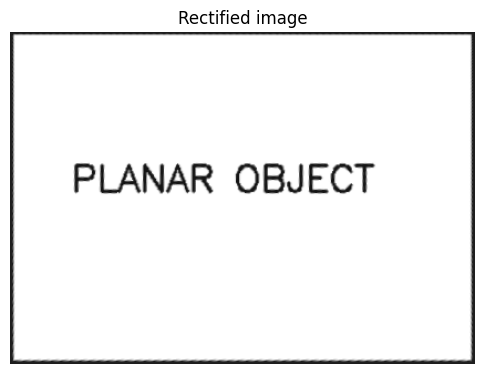

In [ ]:
input_img = perspective_view.copy()
## define the rectified image size and target corner points
output_size = (420, 300)
target_points = np.float32([[0, 0], [output_size[0]-1, 0],
                            [output_size[0]-1, output_size[1]-1], [0, output_size[1]-1]])
## identify corner points in the perspective image 
corner_points = # write your code here to identify points, you can use the known corner points. Or use previous learned feature detection methods
H = # write your code here to compute the homography matrix using the identified corner points and target points
rectified_project = cv2.warpPerspective(input_img, H, output_size)
show_image(rectified_project, 'Rectified image')



# Run Canny edge detection on the rectified image.


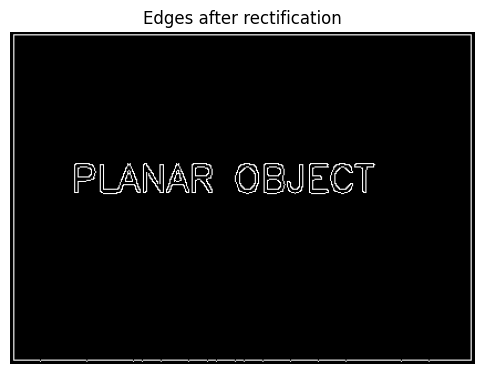

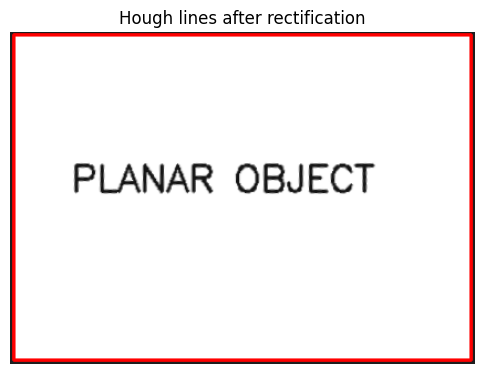

Number of detected line segments: 4


In [ ]:
rectified_gray = cv2.cvtColor(rectified_project, cv2.COLOR_RGB2GRAY)
rectified_edges = # write your code here to perform edge detection on the rectified image, you can reuse the parameters from the previous edge detection step

project_lines = ## write your code here, select a hough transformation method and set appropriate parameters for line detection
project_out = rectified_project.copy()
if project_lines is not None:
    for x1, y1, x2, y2 in project_lines[:, 0, :]:
        cv2.line(project_out, (x1, y1), (x2, y2), (255, 0, 0), 2)

show_image(rectified_edges, 'Edges after rectification')
show_image(project_out, 'Hough lines after rectification')
print('Number of detected line segments:', 0 if project_lines is None else len(project_lines))

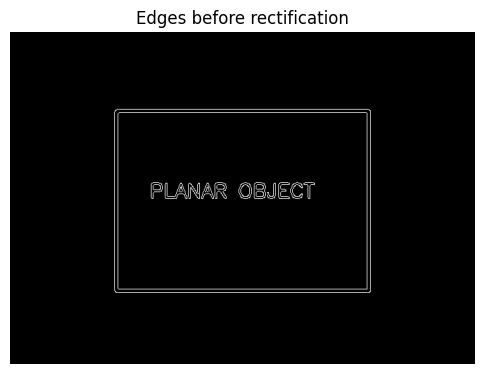

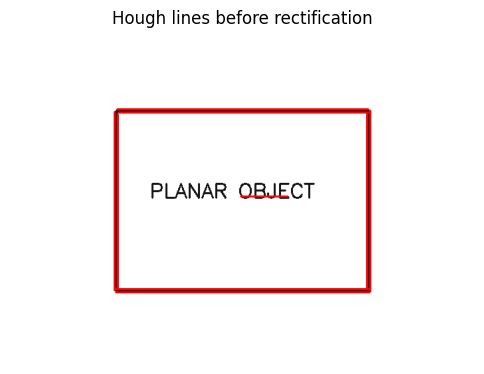

Number of detected line segments: 9


In [ ]:
# Run line  detection on the original image.
out = img_doc.copy()
gray = cv2.cvtColor(img_doc, cv2.COLOR_RGB2GRAY)
edges =# write your code here to perform edge detection on the original image, you can reuse the parameters from the previous edge detection step

lines = ## write your code here, select a hough transformation method and set appropriate parameters for line detection
if lines is not None:
    for x1, y1, x2, y2 in lines[:, 0, :]:
        cv2.line(out, (x1, y1), (x2, y2), (255, 0, 0), 2)

show_image(edges, 'Edges before rectification')
show_image(out, 'Hough lines before rectification')
print('Number of detected line segments:', 0 if lines is None else len(lines))                           


Discuss whether rectification makes line detection easier.
